# Student Dropout — Preprocessing Pipeline
**Flow:** Decoding → Feature Engineering → Encoding → Train-Test Split → View Definition → Scaling per View → Save

> Semua preprocessing dilakukan di level global terlebih dahulu, kemudian baru dibagi per view dan discaling terpisah untuk menghindari data leakage.

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
TEST_SIZE    = 0.2

---
## 1. Load Raw Data

In [2]:
data = pd.read_csv("../data/data.csv", delimiter=";")
df   = data.copy()
print(f"Shape: {df.shape}")
df.head(3)

Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


---
## 2. Categorical Decoding (sama dengan EDA)

In [3]:
# ── Fix tab in column name ──────────────────────────────────────────────────
df.rename(columns={'Daytime/evening attendance\t': 'Attendance'}, inplace=True)

# ── Application mode ────────────────────────────────────────────────────────
app_mode_map = {
    1:'1st phase - general contingent', 2:'Ordinance No. 612/93',
    5:'1st phase - special contingent (Azores)', 7:'Holders of other higher courses',
    10:'Ordinance No. 854-B/99', 15:'International student (bachelor)',
    16:'1st phase - special contingent (Madeira)', 17:'2nd phase - general contingent',
    18:'3rd phase - general contingent', 26:'Ordinance No. 533-A/99 b2',
    27:'Ordinance No. 533-A/99 b3', 39:'Over 23 years old',
    42:'Transfer', 43:'Change of course', 44:'Technological specialization diploma',
    51:'Change of institution/course', 53:'Short cycle diploma',
    57:'Change of institution/course (International)'
}
df['Application mode'] = df['Application mode'].map(app_mode_map)

# ── Course ──────────────────────────────────────────────────────────────────
course_map = {
    33:'Biofuel Production Technologies', 171:'Animation and Multimedia Design',
    8014:'Social Service (evening)', 9003:'Agronomy', 9070:'Communication Design',
    9085:'Veterinary Nursing', 9119:'Informatics Engineering', 9130:'Equinculture',
    9147:'Management', 9238:'Social Service', 9254:'Tourism', 9500:'Nursing',
    9556:'Oral Hygiene', 9670:'Advertising and Marketing Management',
    9773:'Journalism and Communication', 9853:'Basic Education',
    9991:'Management (evening)'
}
df['Course'] = df['Course'].map(course_map)

# ── Previous qualification ───────────────────────────────────────────────────
prev_qual_map = {
    1:'Secondary education', 2:"Higher ed - bachelor's", 3:'Higher ed - degree',
    4:"Higher ed - master's", 5:'Higher ed - doctorate', 6:'Frequency of higher ed',
    9:'12th year - not completed', 10:'11th year - not completed',
    12:'Other - 11th year', 14:'10th year', 15:'10th year - not completed',
    19:'Basic ed 3rd cycle', 38:'Basic ed 2nd cycle',
    39:'Technological specialization', 40:'Higher ed - degree (1st cycle)',
    42:'Professional higher technical', 43:'Higher ed - master (2nd cycle)'
}
df['Previous qualification'] = df['Previous qualification'].map(prev_qual_map)

# ── Nationality ──────────────────────────────────────────────────────────────
nat_map = {
    1:'Portuguese', 2:'German', 6:'Spanish', 11:'Italian', 13:'Dutch',
    14:'English', 17:'Lithuanian', 21:'Angolan', 22:'Cape Verdean', 24:'Guinean',
    25:'Mozambican', 26:'Santomean', 32:'Turkish', 41:'Brazilian', 62:'Romanian',
    100:'Moldovan', 101:'Mexican', 103:'Ukrainian', 105:'Russian', 108:'Cuban',
    109:'Colombian'
}
df['Nacionality'] = df['Nacionality'].map(nat_map)

# ── Mother & Father qualification ────────────────────────────────────────────
parent_qual_map = {
    1:'Secondary - 12th', 2:"Higher - Bachelor's", 3:'Higher - Degree',
    4:"Higher - Master's", 5:'Higher - Doctorate', 6:'Freq Higher Ed',
    9:'12th - Not Completed', 10:'11th - Not Completed', 11:'7th Year (Old)',
    12:'Other - 11th', 13:'2nd year comp high school', 14:'10th Year',
    18:'General commerce', 19:'Basic 3rd Cycle', 20:'Comp High School',
    22:'Technical-professional', 25:'Comp High School - not concluded',
    26:'7th year schooling', 27:'2nd cycle general high school',
    29:'9th Year - Not Completed', 30:'8th year schooling',
    31:'General Admin and Commerce', 33:'Supplementary Accounting',
    34:'Unknown', 35:"Can't read/write", 36:'Can read - no 4th year',
    37:'Basic 1st cycle', 38:'Basic 2nd Cycle', 39:'Technological specialization',
    40:'Higher - degree (1st cycle)', 41:'Specialized higher studies',
    42:'Professional higher technical', 43:'Higher - Master (2nd cycle)',
    44:'Higher - Doctorate (3rd cycle)'
}
df["Mother's qualification"] = df["Mother's qualification"].map(parent_qual_map)
df["Father's qualification"] = df["Father's qualification"].map(parent_qual_map)

# ── Mother & Father occupation ───────────────────────────────────────────────
occ_map = {
    0:'Student', 1:'Managers', 2:'Specialists/Scientific',
    3:'Intermediate Technicians', 4:'Administrative',
    5:'Personal Services/Sellers', 6:'Skilled Agricultural',
    7:'Skilled Industry/Construction', 8:'Machine Operators',
    9:'Unskilled Workers', 10:'Armed Forces', 90:'Other', 99:'Blank',
    101:'Armed Forces Officers', 102:'Armed Forces Sergeants',
    103:'Other Armed Forces', 112:'Admin/Commercial Directors',
    114:'Hotel/Trade Directors', 121:'Physical Sciences/Engineering Specialists',
    122:'Health Professionals', 123:'Teachers', 124:'Finance/Admin Specialists',
    125:'ICT Specialists', 131:'Science/Engineering Technicians',
    132:'Health Technicians', 134:'Legal/Social/Cultural Technicians',
    135:'ICT Technicians', 141:'Office/Secretaries',
    143:'Accounting/Financial Operators', 144:'Other Admin Support',
    151:'Personal Service Workers', 152:'Sellers', 153:'Personal Care',
    154:'Protection/Security', 161:'Skilled Farmers',
    163:'Subsistence Farmers', 171:'Skilled Construction',
    172:'Metallurgy/Metalworking', 173:'Printing/Precision/Jewelry',
    174:'Electricity/Electronics', 175:'Food/Wood/Clothing Industry',
    181:'Fixed Plant Operators', 182:'Assembly Workers',
    183:'Vehicle Drivers', 191:'Cleaning Workers',
    192:'Unskilled Agricultural', 193:'Unskilled Extractive/Construction',
    194:'Meal Preparation', 195:'Street Vendors'
}
df["Mother's occupation"] = df["Mother's occupation"].map(occ_map)
df["Father's occupation"] = df["Father's occupation"].map(occ_map)

# ── Binary columns ───────────────────────────────────────────────────────────
df['Gender']                    = df['Gender']                    # 1=Male, 0=Female — keep as is
df['Attendance']                = df['Attendance']                # 1=Daytime, 0=Evening
# already 0/1: Displaced, Educational special needs, Debtor,
# Tuition fees up to date, Scholarship holder, International

# ── Marital status ───────────────────────────────────────────────────────────
marital_map = {1:'Single', 2:'Married', 3:'Widower', 4:'Divorced',
               5:'Facto union', 6:'Legally separated'}
df['Marital status'] = df['Marital status'].map(marital_map)

print("Decoding done.")
print(f"Shape: {df.shape}")
df.head(2)

Decoding done.
Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,Single,2nd phase - general contingent,5,Animation and Multimedia Design,1,Secondary education,122.0,Portuguese,Basic 3rd Cycle,Other - 11th,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,International student (bachelor),1,Tourism,1,Secondary education,160.0,Portuguese,Secondary - 12th,Higher - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate


---
## 3. Global Feature Engineering
Semua fitur baru dibuat di sini sebelum split, supaya tidak ada view yang ketinggalan fitur.

In [4]:
# ── Academic performance features ────────────────────────────────────────────

# Approval rate (approved / enrolled), avoid division by zero
df['Approval_rate_1st'] = np.where(
    df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'], 0)

df['Approval_rate_2nd'] = np.where(
    df['Curricular units 2nd sem (enrolled)'] > 0,
    df['Curricular units 2nd sem (approved)'] / df['Curricular units 2nd sem (enrolled)'], 0)

# Grade improvement: positive = improving, negative = declining
df['Grade_improvement'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']

# Total approved across both semesters
df['Total_approved'] = (df['Curricular units 1st sem (approved)'] +
                        df['Curricular units 2nd sem (approved)'])

# Total enrolled across both semesters
df['Total_enrolled'] = (df['Curricular units 1st sem (enrolled)'] +
                        df['Curricular units 2nd sem (enrolled)'])

# Overall approval rate across both semesters
df['Approval_rate_overall'] = np.where(
    df['Total_enrolled'] > 0,
    df['Total_approved'] / df['Total_enrolled'], 0)

# Average grade across both semesters
df['Grade_avg'] = (df['Curricular units 1st sem (grade)'] +
                   df['Curricular units 2nd sem (grade)']) / 2

# Grade consistency (std across semesters — 0 means perfect consistency)
df['Grade_consistency'] = df[['Curricular units 1st sem (grade)',
                               'Curricular units 2nd sem (grade)']].std(axis=1)

# Zero evaluations flag — ghost student signal
df['Zero_eval_1st'] = (df['Curricular units 1st sem (evaluations)'] == 0).astype(int)
df['Zero_eval_2nd'] = (df['Curricular units 2nd sem (evaluations)'] == 0).astype(int)
df['Zero_eval_both'] = (df['Zero_eval_1st'] & df['Zero_eval_2nd']).astype(int)

# Evaluation intensity (evaluations per enrolled unit) — how hard they tried
df['Eval_intensity_1st'] = np.where(
    df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (evaluations)'] / df['Curricular units 1st sem (enrolled)'], 0)

df['Eval_intensity_2nd'] = np.where(
    df['Curricular units 2nd sem (enrolled)'] > 0,
    df['Curricular units 2nd sem (evaluations)'] / df['Curricular units 2nd sem (enrolled)'], 0)

# ── Financial features ───────────────────────────────────────────────────────
# Financial risk score: higher = more at-risk
df['Financial_risk_score'] = (
    (df['Tuition fees up to date'] == 0).astype(int) +
    df['Debtor'] +
    (df['Scholarship holder'] == 0).astype(int)
)

# ── Demographic features ─────────────────────────────────────────────────────
# Older student flag (age >= 25 when enrolled)
df['Is_older_student'] = (df['Age at enrollment'] >= 25).astype(int)

# Is evening student (0 = evening attendance)
df['Is_evening'] = (df['Attendance'] == 0).astype(int)

# Is international student
df['Is_international_nat'] = (df['Nacionality'] != 'Portuguese').astype(int)

# ── Grade vs admission baseline (over/underperforming) ──────────────────────
# Normalize admission grade to same scale as curricular grades (admission is 0-200, curricular 0-20)
df['Admission_grade_norm']        = df['Admission grade'] / 20
df['Prev_qual_grade_norm']        = df['Previous qualification (grade)'] / 20
df['Grade_vs_admission']          = df['Grade_avg'] - df['Admission_grade_norm']

print("Feature engineering done.")
engineered_cols = [
    'Approval_rate_1st', 'Approval_rate_2nd', 'Grade_improvement', 'Total_approved',
    'Total_enrolled', 'Approval_rate_overall', 'Grade_avg', 'Grade_consistency',
    'Zero_eval_1st', 'Zero_eval_2nd', 'Zero_eval_both',
    'Eval_intensity_1st', 'Eval_intensity_2nd', 'Financial_risk_score',
    'Is_older_student', 'Is_evening', 'Is_international_nat',
    'Admission_grade_norm', 'Prev_qual_grade_norm', 'Grade_vs_admission'
]
print(f"New features added: {len(engineered_cols)}")
print(f"Total features now: {df.shape[1]}")
df[engineered_cols].describe().round(3)

Feature engineering done.
New features added: 20
Total features now: 57


,Approval_rate_1st,Approval_rate_2nd,Grade_improvement,Total_approved,Total_enrolled,Approval_rate_overall,Grade_avg,Grade_consistency,Zero_eval_1st,Zero_eval_2nd,Zero_eval_both,Eval_intensity_1st,Eval_intensity_2nd,Financial_risk_score,Is_older_student,Is_evening,Is_international_nat,Admission_grade_norm,Prev_qual_grade_norm,Grade_vs_admission
count,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000,4424.000
mean,0.698,0.660,-0.411,9.142,12.503,0.679,10.436,0.891,0.079,0.091,0.078,1.290,1.261,0.985,0.257,0.109,0.025,6.349,6.631,4.087
std,0.365,0.383,2.890,5.961,4.609,0.362,4.819,1.862,0.270,0.287,0.268,0.567,0.579,0.731,0.437,0.312,0.156,0.724,0.659,4.817
min,0.000,0.000,-16.143,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.750,4.750,-8.980
25%,0.500,0.400,-0.600,5.000,10.000,0.500,11.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,0.000,0.000,5.895,6.250,4.550
50%,0.833,0.833,0.000,10.000,12.000,0.833,12.250,0.354,0.000,0.000,0.000,1.200,1.167,1.000,0.000,0.000,0.000,6.305,6.655,5.958
75%,1.000,1.000,0.452,12.000,14.000,1.000,13.267,0.825,0.000,0.000,0.000,1.600,1.600,1.000,1.000,0.000,0.000,6.740,7.000,6.942
max,1.000,1.000,16.000,43.000,46.000,1.000,18.284,11.415,1.000,1.000,1.000,3.500,3.833,3.000,1.000,1.000,1.000,9.500,9.500,11.250


---
## 4. Target Encoding

In [5]:
target_map = {'Graduate': 0, 'Enrolled': 1, 'Dropout': 2}
df['Target_encoded'] = df['Target'].map(target_map)

print("Target mapping:")
for k, v in target_map.items():
    n = (df['Target_encoded'] == v).sum()
    print(f"  {v} → {k}: {n:,} ({n/len(df)*100:.1f}%)")

y = df['Target_encoded'].values

Target mapping:
  0 → Graduate: 2,209 (49.9%)
  1 → Enrolled: 794 (17.9%)
  2 → Dropout: 1,421 (32.1%)


---
## 5. Define Feature Views
Semua fitur (asli + engineered) dibagi ke dalam 4 view berdasarkan domain semantik.

In [6]:
# ────────────────────────────────────────────────────────────────────────────
# VIEW 1: Academic Performance View
# Semua yang berkaitan dengan aktivitas dan hasil akademik di kampus
# ────────────────────────────────────────────────────────────────────────────
academic_features = [
    'Previous qualification (grade)',
    'Admission grade',
    'Admission_grade_norm',
    'Prev_qual_grade_norm',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    # Engineered
    'Approval_rate_1st', 'Approval_rate_2nd', 'Approval_rate_overall',
    'Grade_improvement', 'Grade_avg', 'Grade_consistency',
    'Total_approved', 'Total_enrolled',
    'Zero_eval_1st', 'Zero_eval_2nd', 'Zero_eval_both',
    'Eval_intensity_1st', 'Eval_intensity_2nd',
    'Grade_vs_admission'
]

# ────────────────────────────────────────────────────────────────────────────
# VIEW 2: Financial View
# Semua yang berkaitan dengan kondisi finansial mahasiswa
# ────────────────────────────────────────────────────────────────────────────
financial_features = [
    'Tuition fees up to date',
    'Debtor',
    'Scholarship holder',
    # Engineered
    'Financial_risk_score'
]

# ────────────────────────────────────────────────────────────────────────────
# VIEW 3: Personal / Demographic View
# Latar belakang pribadi, keluarga, dan jalur masuk mahasiswa
# Perlu encoding untuk fitur kategorical high-cardinality
# ────────────────────────────────────────────────────────────────────────────
demographic_features_raw = [
    'Gender', 'Age at enrollment', 'Displaced', 'Educational special needs',
    'International', 'Attendance', 'Application order',
    # Engineered
    'Is_older_student', 'Is_evening', 'Is_international_nat'
]
demographic_cat_features = [
    'Marital status', 'Application mode', 'Course', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]
demographic_features = demographic_features_raw + demographic_cat_features

# ────────────────────────────────────────────────────────────────────────────
# VIEW 4: Macro-Economic View
# Kondisi ekonomi saat mahasiswa terdaftar
# ────────────────────────────────────────────────────────────────────────────
macro_features = [
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

print(f"VIEW 1 — Academic    : {len(academic_features)} features")
print(f"VIEW 2 — Financial   : {len(financial_features)} features")
print(f"VIEW 3 — Demographic : {len(demographic_features)} features")
print(f"VIEW 4 — Macro       : {len(macro_features)} features")

VIEW 1 — Academic    : 30 features
VIEW 2 — Financial   : 4 features
VIEW 3 — Demographic : 19 features
VIEW 4 — Macro       : 3 features


---
## 6. Train-Test Split (Stratified)
Split dilakukan **sebelum** encoding dan scaling untuk mencegah data leakage.

In [7]:
# Ambil semua fitur yang akan dipakai
all_features_needed = list(set(
    academic_features + financial_features + demographic_features + macro_features
))

X_raw = df[all_features_needed].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size : {len(X_train_raw):,} ({len(X_train_raw)/len(X_raw)*100:.1f}%)")
print(f"Test size  : {len(X_test_raw):,} ({len(X_test_raw)/len(X_raw)*100:.1f}%)")
print(f"\nClass distribution (train):")
for cls, name in {0:'Graduate', 1:'Enrolled', 2:'Dropout'}.items():
    n = (y_train == cls).sum()
    print(f"  {name}: {n} ({n/len(y_train)*100:.1f}%)")
print(f"\nClass distribution (test):")
for cls, name in {0:'Graduate', 1:'Enrolled', 2:'Dropout'}.items():
    n = (y_test == cls).sum()
    print(f"  {name}: {n} ({n/len(y_test)*100:.1f}%)")

Train size : 3,539 (80.0%)
Test size  : 885 (20.0%)

Class distribution (train):
  Graduate: 1767 (49.9%)
  Enrolled: 635 (17.9%)
  Dropout: 1137 (32.1%)

Class distribution (test):
  Graduate: 442 (49.9%)
  Enrolled: 159 (18.0%)
  Dropout: 284 (32.1%)


---
## 7. Categorical Encoding — Demographic View
Strategi:
- **Frequency Encoding** untuk high-cardinality (nationality, course, app mode, occ, qual)
- Fit encoder **hanya pada train** → transform test
- Alasan pilih Frequency Encoding: works baik untuk semua model type (tree, distance-based), tidak explode dimensi seperti OHE, tidak leakage seperti target encoding yang naif

In [8]:
def fit_frequency_encoders(train_df, cat_cols):
    """Fit frequency encoders on train data only."""
    encoders = {}
    for col in cat_cols:
        freq_map = train_df[col].value_counts(normalize=True).to_dict()
        encoders[col] = freq_map
    return encoders

def apply_frequency_encoders(df_in, encoders):
    """Apply fitted frequency encoders, unseen categories → global mean freq."""
    df_out = df_in.copy()
    for col, freq_map in encoders.items():
        default_val = np.mean(list(freq_map.values()))
        df_out[col] = df_out[col].map(freq_map).fillna(default_val)
    return df_out

# Fit on train
freq_encoders = fit_frequency_encoders(X_train_raw, demographic_cat_features)

# Apply to train and test
X_train_encoded = apply_frequency_encoders(X_train_raw, freq_encoders)
X_test_encoded  = apply_frequency_encoders(X_test_raw,  freq_encoders)

# Verify no NaN after encoding
nan_count = X_train_encoded.isnull().sum().sum()
print(f"NaN after encoding (train): {nan_count}")
nan_count = X_test_encoded.isnull().sum().sum()
print(f"NaN after encoding (test) : {nan_count}")
print("Categorical encoding done — all features now numeric.")

NaN after encoding (train): 0
NaN after encoding (test) : 0
Categorical encoding done — all features now numeric.


---
## 8. Build Views + Scaling per View

Scaling strategy per view:
- **Academic View** → `StandardScaler` (grades dan counts beda skala)
- **Financial View** → `MinMaxScaler` / no scaling needed (semua sudah 0–3), tapi StandardScaler untuk konsistensi
- **Demographic View** → `StandardScaler` (age + freq encoded categories)
- **Macro View** → `StandardScaler` (unemployment 7-16, GDP -4 to +3.5, inflation -0.8 to 3.7)

> **CRITICAL:** Scaler di-fit HANYA di train, lalu di-transform ke test. Ini mutlak.

In [9]:
views_config = {
    'academic'     : academic_features,
    'financial'    : financial_features,
    'demographic'  : demographic_features,
    'macro'        : macro_features
}

views_train = {}
views_test  = {}
scalers     = {}

for view_name, feat_list in views_config.items():
    # Extract view
    X_tr = X_train_encoded[feat_list].values.astype(float)
    X_te = X_test_encoded[feat_list].values.astype(float)

    # Fit scaler on train only
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    views_train[view_name] = X_tr_scaled
    views_test[view_name]  = X_te_scaled
    scalers[view_name]     = scaler

    print(f"View [{view_name:15s}] → Train: {X_tr_scaled.shape} | Test: {X_te_scaled.shape} "
          f"| Mean≈{X_tr_scaled.mean():.2e} Std≈{X_tr_scaled.std():.3f}")

print("\nAll views built and scaled.")

View [academic       ] → Train: (3539, 30) | Test: (885, 30) | Mean≈1.36e-16 Std≈1.000
View [financial      ] → Train: (3539, 4) | Test: (885, 4) | Mean≈2.58e-17 Std≈1.000
View [demographic    ] → Train: (3539, 19) | Test: (885, 19) | Mean≈9.94e-17 Std≈1.000
View [macro          ] → Train: (3539, 3) | Test: (885, 3) | Mean≈-1.69e-16 Std≈1.000

All views built and scaled.


---
## 9. Verification — Check Data Quality

In [10]:
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

for view_name in views_train:
    X_tr = views_train[view_name]
    X_te = views_test[view_name]
    has_nan_tr = np.isnan(X_tr).any()
    has_nan_te = np.isnan(X_te).any()
    has_inf_tr = np.isinf(X_tr).any()
    has_inf_te = np.isinf(X_te).any()
    status = "✓" if not (has_nan_tr or has_nan_te or has_inf_tr or has_inf_te) else "✗ ISSUE"
    print(f"  {view_name:15s} {status} | NaN(tr={has_nan_tr},te={has_nan_te}) | Inf(tr={has_inf_tr},te={has_inf_te})")

print(f"\nTarget distribution in train:")
unique, counts = np.unique(y_train, return_counts=True)
label_names = {0:'Graduate', 1:'Enrolled', 2:'Dropout'}
for u, c in zip(unique, counts):
    print(f"  {label_names[u]}: {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nFeature counts per view:")
for vn, fl in views_config.items():
    print(f"  {vn:15s}: {len(fl)} features")

DATA QUALITY CHECK
  academic        ✓ | NaN(tr=False,te=False) | Inf(tr=False,te=False)
  financial       ✓ | NaN(tr=False,te=False) | Inf(tr=False,te=False)
  demographic     ✓ | NaN(tr=False,te=False) | Inf(tr=False,te=False)
  macro           ✓ | NaN(tr=False,te=False) | Inf(tr=False,te=False)

Target distribution in train:
  Graduate: 1767 (49.9%)
  Enrolled: 635 (17.9%)
  Dropout: 1137 (32.1%)

Feature counts per view:
  academic       : 30 features
  financial      : 4 features
  demographic    : 19 features
  macro          : 3 features


---
## 10. Visualize Feature Distribution per View (Sanity Check)

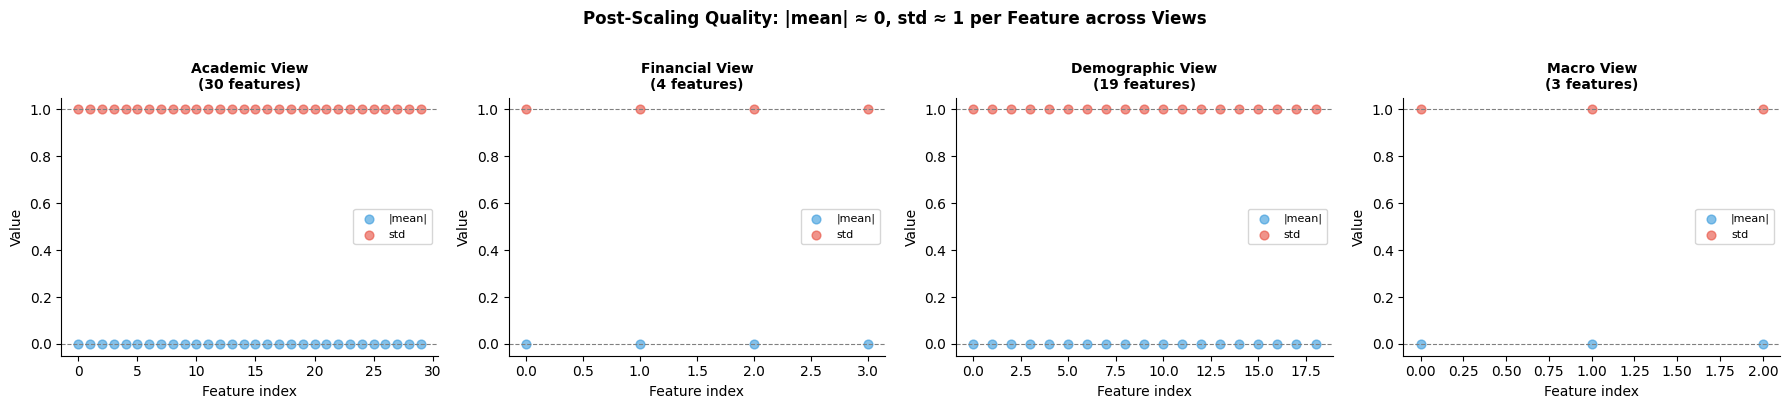

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (view_name, feat_list) in zip(axes, views_config.items()):
    X_tr = views_train[view_name]
    # Plot distribution of mean absolute values per feature (should be ~0 after StandardScaler)
    feature_means = np.abs(X_tr.mean(axis=0))
    feature_stds  = X_tr.std(axis=0)
    ax.scatter(range(len(feat_list)), feature_means, alpha=0.6, color='#3498db', s=40, label='|mean|')
    ax.scatter(range(len(feat_list)), feature_stds,  alpha=0.6, color='#e74c3c', s=40, label='std')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(1, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{view_name.capitalize()} View\n({len(feat_list)} features)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Feature index'); ax.set_ylabel('Value')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Post-Scaling Quality: |mean| ≈ 0, std ≈ 1 per Feature across Views',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 11. Save All Preprocessed Data

In [12]:
preprocessed_bundle = {
    # Views (scaled)
    'views_train'    : views_train,
    'views_test'     : views_test,
    # Labels
    'y_train'        : y_train,
    'y_test'         : y_test,
    # Metadata
    'views_config'   : views_config,
    'scalers'        : scalers,
    'freq_encoders'  : freq_encoders,
    'target_map'     : target_map,
    'label_names'    : label_names,
    # Feature names per view (for SHAP later)
    'feature_names'  : {vn: fl for vn, fl in views_config.items()}
}

with open('../data/preprocessed_bundle.pkl', 'wb') as f:
    pickle.dump(preprocessed_bundle, f)

print("Saved: ../data/preprocessed_bundle.pkl")
print("\nBundle contents:")
for key, val in preprocessed_bundle.items():
    if isinstance(val, dict):
        if key == 'views_train' or key == 'views_test':
            for vn, arr in val.items():
                print(f"  {key}[{vn}]: shape {arr.shape}")
        else:
            print(f"  {key}: dict with {len(val)} keys")
    elif isinstance(val, np.ndarray):
        print(f"  {key}: shape {val.shape}")
    else:
        print(f"  {key}: {type(val).__name__}")

Saved: ../data/preprocessed_bundle.pkl

Bundle contents:
  views_train[academic]: shape (3539, 30)
  views_train[financial]: shape (3539, 4)
  views_train[demographic]: shape (3539, 19)
  views_train[macro]: shape (3539, 3)
  views_test[academic]: shape (885, 30)
  views_test[financial]: shape (885, 4)
  views_test[demographic]: shape (885, 19)
  views_test[macro]: shape (885, 3)
  y_train: shape (3539,)
  y_test: shape (885,)
  views_config: dict with 4 keys
  scalers: dict with 4 keys
  freq_encoders: dict with 9 keys
  target_map: dict with 3 keys
  label_names: dict with 3 keys
  feature_names: dict with 4 keys


---
## Summary

```
PREPROCESSING PIPELINE COMPLETE
═══════════════════════════════════════════════════════════════

Input  : 4,424 students × 37 raw features
After FE: 4,424 students × ~57 features (+ 20 engineered)
Split  : 80% train (3,539) | 20% test (885) — stratified

Encoding:
  • Binary features   → already 0/1, no change
  • High-cardinality  → Frequency Encoding (fit on train only)
  • Scaling           → StandardScaler per view (fit on train only)

Views ready for modeling:
  VIEW 1 — Academic     : ~30 features
  VIEW 2 — Financial    :   4 features
  VIEW 3 — Demographic  : ~19 features
  VIEW 4 — Macro        :   3 features

Next step → 03_multiview_stacking.ipynb
═══════════════════════════════════════════════════════════════
```